In [309]:
import os
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

Image we're using:

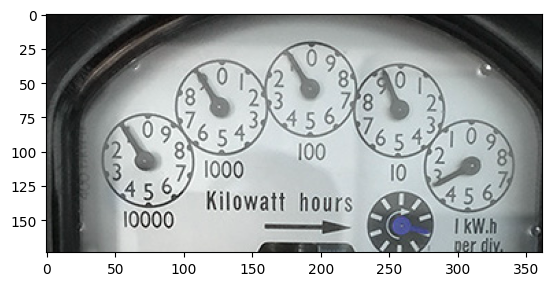

In [310]:
img = cv2.imread('dialmeter1.jpg')
#img = cv2.imread('dialmeter2.jpg')
expected_value = 19093
plt.imshow(img)

There's 36 degrees between each number. So, depending on the angle of the pointer, we can get the value.  
- First, third, and fifth dials: CW
    - Value (degrees):
        - 0: [90, 54)
        - 1: [54, 18)
        - 2: [18, 342)
        - 3: [342, 306)
        - 4: [306, 270)
        - 5: [270, 234)
        - 6: [234, 198)
        - 7: [198, 162)
        - 8: [162, 126)
        - 9: [126, 90)
- Second and fourth dials: CCW  
    - Value (degrees):
        - 0: [90, 126)
        - 1: [126, 162)
        - 2: [162, 198)
        - 3: [198, 234)
        - 4: [234, 270)
        - 5: [270, 306)
        - 6: [306, 342)
        - 7: [342, 18)
        - 8: [18, 54)
        - 9: [54, 90)

(( these are supposed to be flipped ))


In [311]:
# value ranges for first, third, and fifth dials
CCW_value_ranges = {
    0: [90, 126],
    1: [126, 162],
    2: [162, 198],
    3: [198, 234],
    4: [234, 270],
    5: [270, 306],
    6: [306, 342],
    7: [342, 18],
    8: [18, 54],
    9: [54, 90]
}

# value ranges for second and fourth dials
CW_value_ranges = {
    0: [90, 54],
    1: [54, 18],
    2: [18, 342],
    3: [342, 306],
    4: [306, 270],
    5: [270, 234],
    6: [234, 198],
    7: [198, 162],
    8: [162, 126],
    9: [126, 90]
}

In [312]:
#def getValue(angle, is_clockwise):
    # if is_clockwise:
    #     for value, angle_range in CW_value_ranges.items():
    #         if angle <= angle_range[0] and angle > angle_range[1]:
    #             return value
    # else:
    #     for value, angle_range in CCW_value_ranges.items():
    #         if angle >= angle_range[0] and angle < angle_range[1]:
    #             return value

def getValue(val, is_clockwise):
    if is_clockwise:
        value = val
    else:
        value = 10. - val
    if value == 10:
        value = 0
    return value

Preprocess the image

In [313]:
def Preprocess(image):
    # tilt correction
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    # lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=100)
    # angle = np.mean([line[0][1] for line in lines])

    # height, width = image.shape[:2]
    # center = (width // 2, height // 2)
    # M = cv2.getRotationMatrix2D(center, -angle, 1.0)
    # rotated = cv2.warpAffine(image, M, (width, height), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    #resized = cv2.resize(image, (350, 150))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gaussian_gray = cv2.GaussianBlur(gray, (5, 5), 0)
    
    return gray, gaussian_gray

Find and outline the dials

In [314]:
# def avg_circles(circles, b):
#     avg_x=0
#     avg_y=0
#     avg_r=0
#     for i in range(b):
#         avg_x += circles[0][i][0]
#         avg_y += circles[0][i][1]
#         avg_r += circles[0][i][2]
#     avg_x = int(avg_x/(b))
#     avg_y = int(avg_y/(b))
#     avg_r = int(avg_r/(b))
#     return avg_x, avg_y, avg_r

In [315]:
def DialDetector(image, gaussian_gray):

    # find the circles
    circles = cv2.HoughCircles(gaussian_gray, cv2.HOUGH_GRADIENT, dp=1, minDist=45, param1=150, param2=90, minRadius=0, maxRadius=0)
    # round all x, y, r values
    circles = np.uint16(np.around(circles))
    
    print("np array of circles (x, y, r)")
    print(circles)
    print(type(circles))
    
    # Sort the circles from left to right (smallest to largest x-value)
    print("\nnp array of circles (x, y, r): sorted")
    circles = circles[0][np.argsort(circles[:, :, 0])]
    print(circles)
    print(type(circles), "\n")
    
    # draw the circles
    for i in circles[0][:5]:
        # draws the outer part of the circle
        cv2.circle(image,(i[0],i[1]),i[2],(0,255,0),2)
        # draws the center of the circle
        cv2.circle(image,(i[0],i[1]),2,(0,0,255),3)
   
    return circles

In [316]:
# def dist_2_pts(x1, y1, x2, y2):
#     return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [317]:
def getPointer(x, y, r, image):
    slices = 40 # = 36
    size = r * 0.8
    factor = 360/slices
    pointer = None
    longest_dark = 0
    value = None
    center = tuple([x,y])
    for i in range(slices):
        angle = i*factor-90
        dark_length = 0
        x2 = x + int(size*np.cos(angle*np.pi/180))
        y2 = y + int(size*np.sin(angle*np.pi/180))
        points_on_line = np.linspace(center, (x2,y2), 255, 2)
        for p in points_on_line:
            point = np.int32(p)
            px = point[0]
            py = point[1]
            b = image[:, :, 0][py, px]
            g = image[:, :, 1][py, px]
            r = image[:, :, 2][py, px]
            gray = (b.astype(int) + g.astype(int) + r.astype(int))/3
            if gray < 130:
                dark_length += 1
            else:
                continue
        if dark_length > longest_dark:
            longest_dark = dark_length
            pointer = tuple(point)
            value = 10*i/slices
    return value, pointer
         


Get the value of each dial

In [318]:
def MeterValue(circles, gray, gaussian_gray, image):
    meter_value = "1"
    i = 1
    values = []
    
    for c in circles[0]:
        
        x, y, r = c[0], c[1], c[2]

        val, tip = getPointer(x, y, r, image)
       

        cv2.line(image, (x, y), tip, (255, 0, 0), 2)

        if i % 2 == 0:
            print(f"Dial {i}:", f"value = {getValue(val, True)}")
            #meter_value += str(getValue(val, True))
            
        else:
            print(f"Dial {i}:", f"value = {getValue(val, False)}")
            #meter_value += str(getValue(val, False))
            
        i += 1
        # mask = np.zeros(gray.shape, dtype=np.uint8)
        # cv2.circle(mask, (x, y), (r), 255, -1)
        # dial = cv2.bitwise_and(gray, gray, mask=mask)
        # _, thresh = cv2.threshold(dial, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        # contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        

        # -------- previous
        # thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 71, 5)
        # cv2.imwrite("thresh.png", thresh)
        # mask = np.zeros_like(thresh)
        # cv2.circle(mask, (x, y), r, 255, -1)
        # thresh = cv2.bitwise_and(thresh, mask)
        # cv2.imwrite(f"thresh_mask_dial_{i}.png", thresh)
        # contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 

        # max_contour = max(contours, key=cv2.contourArea)
        # cv2.drawContours(image, max_contour, -1, (0, 0, 150), 2)
       
        # if max_contour is not None:
        #     center = (int(x), int(y))
        #     #rows, cols = gray.shape[:2]
        #     [vx,vy,x,y] = cv2.fitLine(max_contour, cv2.DIST_L2,0,0.01,0.01)
        #     #lefty = int((-x*vy/vx)+y)
        #     #righty = int(((cols-x)*vy/vx)+y)
        #     line_length = int(r * 1.1)
        #     x1 = int(center[0] - vx * line_length)
        #     y1 = int(center[1] - vy * line_length)
        #     x2 = int(center[0] + vx * line_length)
        #     y2 = int(center[1] + vy * line_length)
        #     #outter = int(center[1] + r)
        #     #cv2.line(image,(cols-1,righty),(0,lefty),(255,0,0),2)
        #     #cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        #     # converting the angle from radians to degrees and subtracting 180 to get the correct (opposite) side of the circle            
        #     angle = np.rad2deg(np.arctan2(-vy, vx)) - 180
        #     # makes angle positive and puts text next to dial/line
        #     if angle < 0:
        #         angle += 360.0
        #     cv2.putText(image, str(int(angle)), (int(x) + 10,int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
        #     # getting the value of the angle pointer
        #     if (i % 2 == 0):
        #         print(f"Dial {i}:", f"value = {getValue(angle, True)},", f"angle = {angle}")
        #         meter_value += str(getValue(angle, True))
        #     else:
        #         print(f"Dial {i}:", f"value = {getValue(angle, False)},", f"angle = {angle}")
        #         meter_value += str(getValue(angle, False))
        #     i += 1
        # --------
        

            
    
    return meter_value

Test

In [319]:
gray, gaussian_gray = Preprocess(img)
dials = DialDetector(img, gaussian_gray)
meter_value = int(MeterValue(dials, gray, gaussian_gray, img))
# print(f"\nmeter value: {meter_value} kWh")
# print(f"expected value: {expected_value} kWh") # value may be 19193
#assert meter_value == expected_value
cv2.imwrite("original.png", img)

np array of circles (x, y, r)
[[[ 74 106  35]
  [256  70  34]
  [126  70  33]
  [194  54  35]
  [310 112  32]]]
<class 'numpy.ndarray'>

np array of circles (x, y, r): sorted
[[[ 74 106  35]
  [126  70  33]
  [194  54  35]
  [256  70  34]
  [310 112  32]]]
<class 'numpy.ndarray'> 

Dial 1: value = 1.0
Dial 2: value = 9.25
Dial 3: value = 1.0
Dial 4: value = 9.5
Dial 5: value = 3.25


True